# DS2000 & DS2001 Programming with Data & Practicum

# Project 1: World Progress

### 80 Points + 8 Extra Credit Points

## Due Friday, February 21 by 10:00PM

In this project, you'll explore data from [Gapminder.org](http://gapminder.org), a website dedicated to providing a fact-based view of the world and how it has changed. That site includes several data visualizations and presentations, but also publishes the raw data that we will use in this project to recreate and extend some of their most famous visualizations.

The Gapminder website collects data from many sources and compiles them into tables that describe many countries around the world. All of the data they aggregate are published in the [Systema Globalis](https://github.com/open-numbers/ddf--gapminder--systema_globalis/blob/master/README.md). Their goal is "to compile all public statistics; Social, Economic and Environmental; into a comparable total dataset." All data sets in this project are copied directly from the Systema Globalis without any changes.

This project is dedicated to [Hans Rosling](https://en.wikipedia.org/wiki/Hans_Rosling) (1948-2017), who championed the use of data to understand and prioritize global development challenges.

### Logistics

**Deadline.** This project is due at 10:00pm on Friday 2/23. Projects will be accepted up to 24 hours (grace period) late for full credit and up to 72 hours late for 90% credit; after 72 hours, the project will not be accepted for credit. It's **much** better to be early than late, so start working now.

**Checkpoint.** For full credit, you must also complete the first 8 questions (Q1.1 - Q1.8), pass all tests, and submit to Gradescope by 10:00pm on **Friday 2/14** for **6 points.** After you've submitted the checkpoint, you may still change your answers before the project deadline - only your final submission will be graded for correctness. 

**Rules.** You are welcome to discuss questions with other students, but don't share the answers. The experience of solving the problems in this project will prepare you for exams (and life). If someone asks you for the answer, resist! Instead, you can demonstrate how you would solve a similar problem.

**Support.** You are not alone! Talk to your classmates and come to office hours.   Your instructor and TA are here to support you.  

**Tests.** The tests that are given are **not comprehensive** and passing the tests for a question **does not** mean that you answered the question correctly. Tests usually only check that your table has the correct column labels. However, more tests will be applied to verify the correctness of your submission in order to assign your final score, so be careful and check your work! You might want to create your own checks along the way to see if your answers make sense. Additionally, before you submit, make sure that none of your cells take a very long time to run (several minutes).

**Free Response Questions.** Make sure that you put the answers to the written questions in the indicated cell we provide. 

**Advice.** Develop your answers incrementally. To perform a complicated table manipulation, break it up into steps, perform each step on a different line, give a new name to each result, and check that each intermediate result is what you expect. You can add any additional names or functions you want to the provided cells. Make sure that you are using distinct and meaningful variable names throughout the notebook. Along that line, **DO NOT** reuse the variable names that we use when we grade your answers. For example, in Question 1 of the Global Poverty section, we ask you to assign an answer to `latest`. Do not reassign the variable name `latest` to anything else in your notebook, otherwise, there is a chance that our tests grade against what `latest` was reassigned to.

You **never** have to use just one line in this project or any others. Use intermediate variables and multiple lines as much as you would like!  

To get started, load `datascience`, `numpy`, `plots`, and `otter`.

In [1]:
from datascience import *
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')

import otter
grader = otter.Notebook("proj1.ipynb")

## 1. Global Population Growth


The global population of humans reached 1 billion around 1800, 3 billion around 1960, and 7 billion around 2011. The potential impact of exponential population growth has concerned scientists, economists, and politicians alike.

The UN Population Division estimates that the world population will likely continue to grow throughout the 21st century, but at a slower rate, perhaps reaching 11 billion by 2100. However, the UN does not rule out scenarios of more extreme growth.

<a href="http://www.pewresearch.org/fact-tank/2015/06/08/scientists-more-worried-than-public-about-worlds-growing-population/ft_15-06-04_popcount/"> 
 <img src="pew_population_projection.png"/> 
</a>

In this section, we will examine some of the factors that influence population growth and how they are changing around the world.

The first table we will consider is the total population of each country over time. Run the cell below.

In [2]:
population = Table.read_table('population.csv')
population = population.with_columns('pop_total', population.column('population_total')).drop('population_total').relabeled('pop_total', 'population_total')
population.show(3)

geo,time,population_total
abw,1800,19286
abw,1801,19286
abw,1802,19286


In [3]:
pop = population.select('population_total')
pop

population_total
19286
19286
19286
19286
19286
19286
19286
19286
19286
19286


**Note:** The population data file can also be found [here](https://github.com/open-numbers/ddf--gapminder--systema_globalis/tree/master/global-regions-datapoints). The data for this project was downloaded in February 2017.

### Bangladesh

In the `population` table, the `geo` column contains three-letter codes established by the [International Organization for Standardization](https://en.wikipedia.org/wiki/International_Organization_for_Standardization) (ISO) in the [Alpha-3](https://en.wikipedia.org/wiki/ISO_3166-1_alpha-3#Current_codes) standard. We will begin by taking a close look at Bangladesh. Inspect the Alpha-3 standard to find the 3-letter code for Bangladesh.

**Question 1.1. (2 pts)** Create a table called `b_pop` that has two columns labeled `time` and `population_total`. The first column should contain the years from 1970 through 2015 (including both 1970 and 2015) and the second should contain the population of Bangladesh in each of those years.

*Hint:*  Table for Question 1.1 shows the expected output.

In [4]:
b_pop = population.where("time", are.between_or_equal_to(
    1970, 2015)).where("geo", "bgd").select("time", "population_total")
b_pop

time,population_total
1970,65048701
1971,66417450
1972,67578486
1973,68658472
1974,69837960
1975,71247153
1976,72930206
1977,74848466
1978,76948378
1979,79141947


In [5]:
grader.check("q1_1")

q1_1 results: All test cases passed!

Table for Question 1.1

<img src="Q1.1_table.PNG"/> 

Run the following cell to create a table called `b_five` that has the population of Bangladesh every five years. At a glance, it appears that the population of Bangladesh has been growing quickly indeed!

In [6]:
b_pop.set_format('population_total', NumberFormatter)

fives = np.arange(1970, 2016, 5) # 1970, 1975, 1980, ...
b_five = b_pop.sort('time').where('time', are.contained_in(fives))
b_five

time,population_total
1970,"65,048,701"
1975,"71,247,153"
1980,"81,364,176"
1985,"93,015,182"
1990,"105,983,136"
1995,"118,427,768"
2000,"131,280,739"
2005,"142,929,979"
2010,"151,616,777"
2015,"160,995,642"


**Question 1.2. (3 pts)**  Assign `initial` to an array that contains the population for every five year interval from **1970 to 2010**. Then, assign `changed` to an array that contains the population for every five year interval from **1975 to 2015**. You should use the `b_five` table from Question 1.1 to create both arrays, first filtering the table to only contain the relevant years.

We have provided the code below that uses `initial` and `changed` in order to add a column to `b_five` called `annual_growth`. Don't worry about the calculation of the growth rates; run the test below to test your solution.

If you are interested in how we came up with the formula for growth rates, consult the [growth rates](https://www.inferentialthinking.com/chapters/03/2/1/growth) section of the textbook.

*Hint:*  Table for Question 1.2 shows the expected output.

In [7]:
initial = b_five.where("time", are.between_or_equal_to(1970,2010)).column(
    "population_total")
changed = b_five.where("time", are.between_or_equal_to(1975,2015)).column(
    "population_total")

b_1970_through_2010 = b_five.where('time', are.below_or_equal_to(2010)) 
b_five_growth = b_1970_through_2010.with_column('annual_growth', 
                                                (changed/initial)**0.2-1)
b_five_growth.set_format('annual_growth', PercentFormatter)

time,population_total,annual_growth
1970,"65,048,701",1.84%
1975,"71,247,153",2.69%
1980,"81,364,176",2.71%
1985,"93,015,182",2.64%
1990,"105,983,136",2.25%
1995,"118,427,768",2.08%
2000,"131,280,739",1.71%
2005,"142,929,979",1.19%
2010,"151,616,777",1.21%


In [8]:
grader.check("q1_2")

q1_2 results: All test cases passed!

Table for Question 1.2

<img src="Q1.2_table.PNG"/> 

While the population has grown every five years since 1970, the annual growth rate decreased dramatically from 1985 to 2005. Let's look at some other information in order to develop a possible explanation. Run the next cell to load three additional tables of measurements about countries over time.

In [9]:
life_expectancy = Table.read_table('life_expectancy.csv')
child_mortality = Table.read_table('child_mortality.csv').relabel(2, 'child_mortality_under_5_per_1000_born')
fertility = Table.read_table('fertility.csv')

The `life_expectancy` table contains a statistic that is often used to measure how long people live, called *life expectancy at birth*. This number, for a country in a given year, [does not measure how long babies born in that year are expected to live](http://blogs.worldbank.org/opendata/what-does-life-expectancy-birth-really-mean). Instead, it measures how long someone would live, on average, if the *mortality conditions* in that year persisted throughout their lifetime. These "mortality conditions" describe what fraction of people at each age survived the year. So, it is a way of measuring the proportion of people that are staying alive, aggregated over different age groups in the population.

Run the following cells below to see `life_expectancy`, `child_mortality`, and `fertility`. Refer back to these tables as they will be helpful for answering further questions!

In [10]:
life_expectancy

geo,time,life_expectancy_years
afg,1800,28.21
afg,1801,28.2
afg,1802,28.19
afg,1803,28.18
afg,1804,28.17
afg,1805,28.16
afg,1806,28.15
afg,1807,28.14
afg,1808,28.13
afg,1809,28.12


In [11]:
child_mortality

geo,time,child_mortality_under_5_per_1000_born
afg,1800,468.6
afg,1801,468.6
afg,1802,468.6
afg,1803,468.6
afg,1804,468.6
afg,1805,468.6
afg,1806,470
afg,1807,470
afg,1808,470
afg,1809,470


In [12]:
fertility

geo,time,children_per_woman_total_fertility
afg,1800,7
afg,1801,7
afg,1802,7
afg,1803,7
afg,1804,7
afg,1805,7
afg,1806,7
afg,1807,7
afg,1808,7
afg,1809,7


**Question 1.3. (2 pts)** Perhaps population is growing more slowly because people aren't living as long. Use the `life_expectancy` table to draw a line graph with the years 1970 and later on the horizontal axis that shows how the *life expectancy at birth* has changed in Bangladesh.

*Hint:*  Graph 1 shows the expected output.

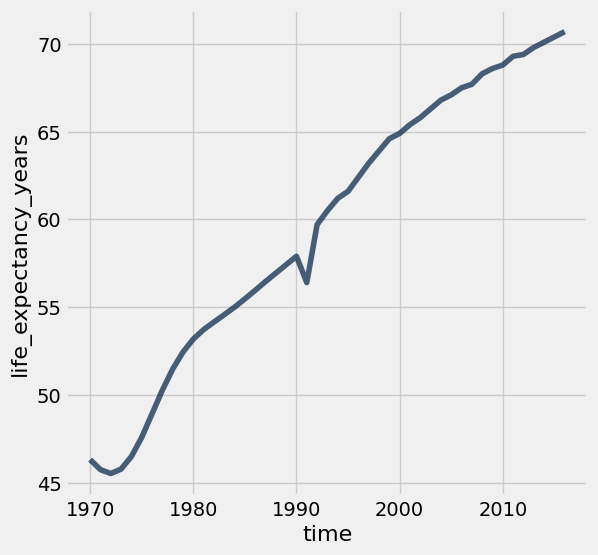

In [13]:
#Fill in code here
life_expectancy.where("time", are.above(1969)).where(
    "geo", "bgd").plot("time", "life_expectancy_years")

Graph 1

<img src="Q1.3_graph.PNG"/> 

**Question 1.4. (3 pts)** Assuming everything else stays the same, do the trends in life expectancy in the graph above directly explain why the population growth rate decreased from 1985 to 2010 in Bangladesh? Why or why not? 

*Hint:* What happened in Bangladesh in 1991, and does that event explain the overall change in population growth rate?

No, the trends do not directly account for the decrease in population growth over this interval, as the graph displays an increase, not decrease, in life expectancy. Additionally, population growth rate depends on many factors, not just life expectancy. An alternate factor to consider, for example, would be natural disasters, like the cyclone in Bangladesh in 1991, which is accounted for on the graph through the dip in life expectancy.

The `fertility` table contains a statistic that is often used to measure how many babies are being born, the *total fertility rate*. This number describes the [number of children a woman would have in her lifetime](https://www.measureevaluation.org/prh/rh_indicators/specific/fertility/total-fertility-rate), on average, if the current rates of birth by age of the mother persisted throughout her child bearing years, assuming she survived through age 49. 

**Question 1.5. (8 pts)** Write a function `fertility_over_time` that takes the Alpha-3 code of a `country` and a `start` year. It returns a two-column table with labels `Year` and `Children per woman` that can be used to generate a line chart of the country's fertility rate each year, starting at the `start` year. The plot should include the `start` year and all later years that appear in the `fertility` table. 

Then, in the next cell, call your `fertility_over_time` function on the Alpha-3 code for Bangladesh and the year 1970 in order to plot how Bangladesh's fertility rate has changed since 1970. Note that the function `fertility_over_time` should not return the plot itself. **The expression that draws the line plot (last line of code) is provided for you; please don't change it.**

*Hint:* Graph 2 displays the expected output.

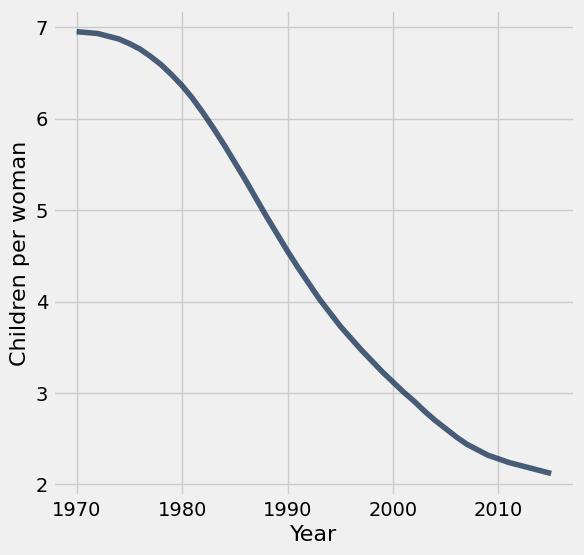

In [14]:
def fertility_over_time(country, start):
    """Create a two-column table that describes a country's total fertility rate each year."""
    country_fertility = fertility.where("geo", country).where(
        "time", are.above_or_equal_to(start)).column(
        "children_per_woman_total_fertility")
    country_fertility_after_start = fertility.where(
        "time", are.above_or_equal_to(start)).where(
        "geo", country).column("time")
    return Table().with_columns("Year", country_fertility_after_start,
                                "Children per woman", country_fertility)

bangladesh_code = "bgd"
fertility_over_time(bangladesh_code, 1970).plot(0, 1) # You should *not* change this line.

In [15]:
grader.check("q1_5")

q1_5 results: All test cases passed!

Graph 2

<img src="Q1.5_graph.PNG"/> 

**Question 1.6. (2 pts)** Assuming everything else is constant, do the trends in fertility in the graph above help directly explain why the population growth rate decreased from 1985 to 2010 in Bangladesh? Why or why not?

The trends in fertility in Bangladesh do help explain the decreased population growth rate, as children per woman is about three times lower in 2017 than in 1970. While the magnitude of this decrease in birth rate would likely make it the primary cause of the decreased population growth rate, it must still be acknowledged that various other factors impact population growth rate.

It has been observed that lower fertility rates are often associated with lower child mortality rates. The link has been attributed to family planning: if parents can expect that their children will all survive into adulthood, then they will choose to have fewer children. We can see if this association is evident in Bangladesh by plotting the relationship between total fertility rate and [child mortality rate per 1000 children](https://en.wikipedia.org/wiki/Child_mortality).

**Question 1.7. (8 pts)** Using both the `fertility` and `child_mortality` tables, draw a scatter diagram that has Bangladesh's total fertility on the horizontal axis and its child mortality on the vertical axis with one point for each year, starting with 1970.

**The expression that draws the scatter diagram is provided for you; please don't change it.** Instead, create a table called `post_1969_fertility_and_child_mortality` with the appropriate column labels and data in order to generate the chart correctly. Use the label `Children per woman` to describe total fertility and the label `Child deaths per 1000 born` to describe child mortality.

*Hint:* Graph 3 displaces the expected output. Use the `join` method to combine the `fertility` and `child_mortality` tables.

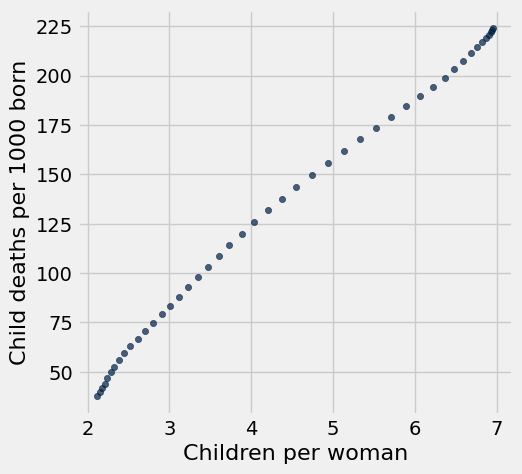

In [16]:
bgd_fertility = fertility_over_time("bgd", 1970)
bgd_child_mortality = child_mortality.where("geo", "bgd").where(
    "time", are.above(1969))
fertility_and_child_mortality = bgd_fertility.join(
    "Year", bgd_child_mortality, "time").select(
    "Children per woman", "child_mortality_under_5_per_1000_born")
post_1969_fertility_and_child_mortality = fertility_and_child_mortality.relabel(
    "child_mortality_under_5_per_1000_born", "Child deaths per 1000 born")

post_1969_fertility_and_child_mortality.scatter('Children per woman', 'Child deaths per 1000 born') # You should *not* change this line.

In [17]:
grader.check("q1_7")

q1_7 results: All test cases passed!

Graph 3

<img src="Q1.7_graph.PNG"/> 

**Question 1.8. (3 pts)** In one or two sentences, describe the association (if any) that is illustrated by this scatter diagram. Does the diagram show that reduced child mortality causes parents to choose to have fewer children?

The graph proves that there is a positive association/correlation between child deaths and the number of children women have - so as child deaths increases, so does the number of children per woman, and vice versa. However, correlation does not imply causation and it cannot be said for sure from the graph whether reduced child mortality causes parents to choose to have fewer children, or even whether parents who have more children also consequently have more child deaths.

---
### Checkpoint, due Friday 2/14 (6 pts)
#### Congratulations, you have reached the checkpoint! Save and submit the notebook to Gradescope for checkpoint submission/credit.
---

### The World

The change observed in Bangladesh since 1970 can also be observed in many other developing countries: health services improve, life expectancy increases, and child mortality decreases. At the same time, the fertility rate often plummets, and so the population growth rate decreases despite increasing longevity.

Run the cell below to generate two overlaid histograms, one for 1960 and one for 2010, that show the distributions of total fertility rates for these two years among all 201 countries in the `fertility` table.

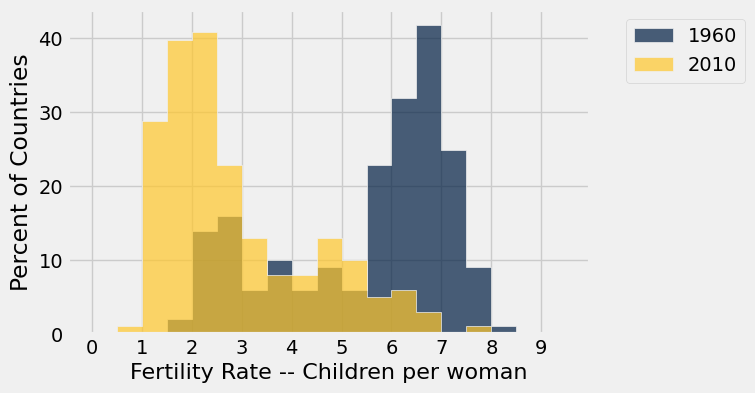

In [18]:
Table().with_columns(
    '1960', fertility.where('time', 1960).column(2),
    '2010', fertility.where('time', 2010).column(2)
).hist(bins=np.arange(0, 10, 0.5), unit='child per woman')
_ = plots.xlabel('Fertility Rate -- Children per woman')
_ = plots.ylabel('Percent of Countries')
_ = plots.xticks(np.arange(10))

**Question 1.9. (3 pts)** Assign `fertility_statements` to an array of the numbers of each statement below that can be correctly inferred from these histograms.
1. About the same number of countries had a fertility rate between 3.5 and 4.5 in both 1960 and 2010.
1. In 2010, about 40% of countries had a fertility rate between 1.5 and 2.
1. In 1960, less than 20% of countries had a fertility rate below 3.
1. More countries had a fertility rate above 3 in 1960 than in 2010.
1. At least half of countries had a fertility rate between 5 and 8 in 1960.
1. At least half of countries had a fertility rate below 3 in 2010.

In [19]:
fertility_statements = make_array(1,3,4,5,6) 

In [20]:
grader.check("q1_9")

q1_9 results: All test cases passed!

**Question 1.10. (3 pts)** Draw a line plot of the world population from 1800 through 2005. The world population is the sum of all the country's populations. 

*Hint:* Graph 4 displays the expected output.

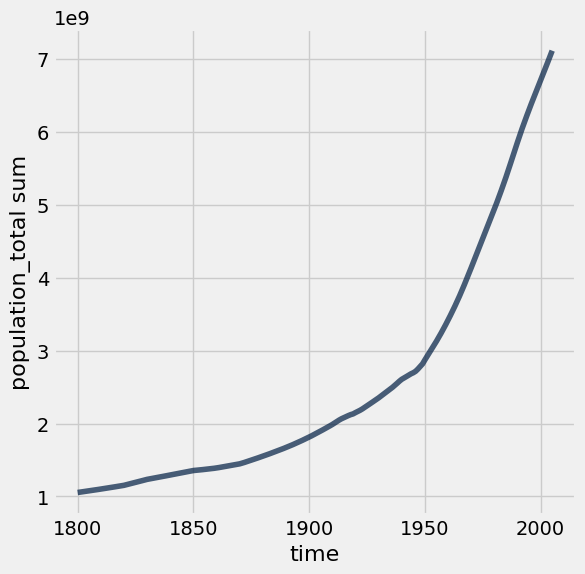

In [21]:
#Fill in code here
population.group("time", sum).where("time", are.between_or_equal_to(
    1800,2005)).plot("time", "population_total sum")

Graph 4

<img src="Q1.10_graph.PNG"/> 

**Question 1.11. (4 pts)** Create a function `stats_for_year` that takes a `year` and returns a table of statistics. The table it returns should have four columns: `geo`, `population_total`, `children_per_woman_total_fertility`, and `child_mortality_under_5_per_1000_born`. Each row should contain one Alpha-3 country code and three statistics: population, fertility rate, and child mortality for that `year` from the `population`, `fertility` and `child_mortality` tables. Only include rows for which all three statistics are available for the country and year.

In addition, restrict the result to country codes that appears in `big_50`, an array of the 50 most populous countries in 2010. This restriction will speed up computations later in the project.

Try calling `stats_for_year` on any year between 1960 and 2010. Try to understand the output of stats_for_year.

*Hint*: Calling `stats_for_year(2008)` (last line) provides the output shown in Table 1.  Compare your output to Table 1.

In [22]:
# We first create a population table that only includes the 
# 50 countries with the largest 2010 populations. We focus on 
# these 50 countries only so that plotting later will run faster.
big_50 = population.where('time', are.equal_to(2010)).sort(
    "population_total", descending=True).take(np.arange(50)).column('geo')
population_of_big_50 = population.where('time', are.above(
    1959)).where('geo', are.contained_in(big_50))

def stats_for_year(year):
    """Return a table of the stats for each country that year."""
    p = population_of_big_50.where('time', are.equal_to(year))
    f = fertility.where('time', are.equal_to(year)).drop('time')
    c = child_mortality.where('time', are.equal_to(year)).drop('time')
    return p.join("geo", f, "geo").join("geo", c, "geo").drop("time")

stats_for_year(2008)

geo,population_total,children_per_woman_total_fertility,child_mortality_under_5_per_1000_born
afg,26528741,6.2,110.4
arg,40381860,2.24,15.4
bgd,148252473,2.38,55.9
bra,194769696,1.9,18.6
can,33363256,1.68,5.8
chn,1326690636,1.53,18.5
cod,61809278,6.45,124.5
col,44901660,2.43,19.7
deu,80665906,1.37,4.4
dza,34811059,2.73,29.5


In [23]:
grader.check("q1_11")

q1_11 results: All test cases passed!

Table 1

 <img src="Q1.11_table.PNG"/> 

**Question 1.12. (5 pts)** Create a table called `pop_by_decade` with two columns called `decade` and `population`. It has a row for each `year` since 1960 that starts a decade. The `population` column contains the total population of all countries included in the result of `stats_for_year(year)` for the first `year` of the decade. For example, 1960 is the first year of the 1960's decade. You should see that these countries contain most of the world's population.

*Hint:* One approach is to define a function `pop_for_year` that computes this total population, then `apply` it to the `decade` column.  The `stats_for_year` function from the previous question may be useful here.

This first test is just a sanity check for your helper function if you choose to use it. You will not lose points for not implementing the function `pop_for_year`.

**Note:** The cell where you will generate the `pop_by_decade` table is below the cell where you can choose to define the helper function `pop_for_year`. You should define your `pop_by_decade` table in the cell that starts with the table `decades` being defined. The expected output is shown as Table 2 below -- check your output against it.

In [24]:
def pop_for_year(year):
    return sum(stats_for_year(year).column("population_total"))

In [25]:
grader.check("q1_12_0")

q1_12_0 results: All test cases passed!

Now that you've defined your helper function (if you've chosen to do so), define the `pop_by_decade` table.

<!--
BEGIN QUESTION
name: q1_12
manual: false
-->

In [26]:
decades = Table().with_column('decade', np.arange(1960, 2011, 10))

pop_by_decade = decades.with_column("population", decades.apply(
    pop_for_year))
pop_by_decade.set_format(1, NumberFormatter)

decade,population
1960,"2,624,944,597"
1970,"3,211,487,418"
1980,"3,880,722,003"
1990,"4,648,434,558"
2000,"5,367,553,063"
2010,"6,040,810,517"


In [27]:
grader.check("q1_12")

q1_12 results: All test cases passed!

Table 2

<img src="Q1.12_table.PNG"/> 

The `countries` table describes various characteristics of countries. The `country` column contains the same codes as the `geo` column in each of the other data tables (`population`, `fertility`, and `child_mortality`). The `world_6region` column classifies each country into a region of the world. Run the cell below to inspect the data.

In [28]:
countries = Table.read_table('countries.csv').where(
    'country', are.contained_in(population.group('geo').column('geo')))
countries.select('country', 'name', 'world_6region')

country,name,world_6region
afg,Afghanistan,south_asia
akr_a_dhe,Akrotiri and Dhekelia,europe_central_asia
alb,Albania,europe_central_asia
dza,Algeria,middle_east_north_africa
asm,American Samoa,east_asia_pacific
and,Andorra,europe_central_asia
ago,Angola,sub_saharan_africa
aia,Anguilla,america
atg,Antigua and Barbuda,america
arg,Argentina,america


**Question 1.13. (3 pts)** Create a table called `region_counts` that has two columns, `region` and `count` corresponding to the number of countries in each region that appear in the result of `stats_for_year(1960)`. For example, one row would have `south_asia` as its `world_6region` value and an integer as its `count` value: the number of large South Asian countries for which we have population, fertility, and child mortality numbers from 1960.

*Hint:* Table 3 displays the expected output.

In [29]:
region_counts = countries.join("country", stats_for_year(
    1960), "geo").group("world_6region").relabel("world_6region", "region")
region_counts

region,count
america,8
east_asia_pacific,10
europe_central_asia,10
middle_east_north_africa,7
south_asia,5
sub_saharan_africa,10


In [30]:
grader.check("q1_13")

q1_13 results: All test cases passed!

Table 3

<img src="Q1.13_table.PNG"/> 

The following scatter diagram compares total fertility rate and child mortality rate for each country in 1960. The area of each dot represents the population of the country, and the color represents its region of the world. Run the cell. Do you think you can identify any of the dots?

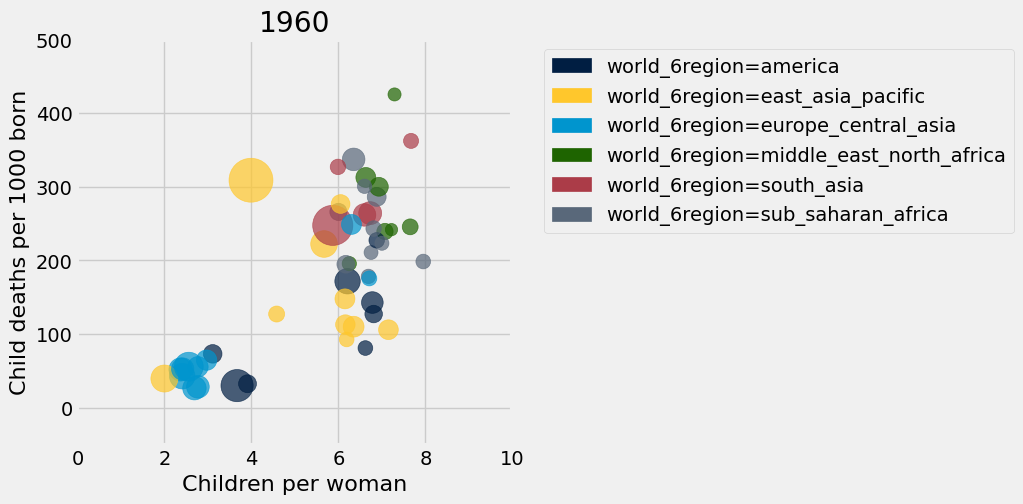

In [31]:
from functools import lru_cache as cache

# This cache annotation makes sure that if the same year
# is passed as an argument twice, the work of computing
# the result is only carried out once.
@cache(None)
def stats_relabeled(year):
    """Relabeled and cached version of stats_for_year."""
    return stats_for_year(year).relabel(2, 'Children per woman').relabel(3, 'Child deaths per 1000 born')

def fertility_vs_child_mortality(year):
    """Draw a color scatter diagram comparing child mortality and fertility."""
    with_region = stats_relabeled(year).join('geo', countries.select('country', 'world_6region'), 'country')
    with_region.scatter(2, 3, sizes=1, group=4, s=500)
    plots.xlim(0,10)
    plots.ylim(-50, 500)
    plots.title(year)

fertility_vs_child_mortality(1960)

**Question 1.14. (2 pts)** Assign `scatter_statements` to an array of the numbers of each statement below that can be inferred from this scatter diagram for 1960. 
1. As a whole, the `europe_central_asia` region had the lowest child mortality rate.
1. The lowest child mortality rate of any country was from an `east_asia_pacific` country.
1. Most countries had a fertility rate above 5.
1. There was an association between child mortality and fertility.
1. The two largest countries by population also had the two highest child mortality rate.


In [32]:
scatter_statements = make_array(1,3,4)

In [33]:
grader.check("q1_14")

q1_14 results: All test cases passed!

Now is a great time to take a break and watch the same data presented by [Hans Rosling in a 2010 TEDx talk](https://www.gapminder.org/videos/reducing-child-mortality-a-moral-and-environmental-imperative) with smoother animation and witty commentary.

## 2. Global Poverty


In 1800, 85% of the world's 1 billion people lived in *extreme poverty*, defined by the United Nations as "a condition characterized by severe deprivation of basic human needs, including food, safe drinking water, sanitation facilities, health, shelter, education and information." A common measure of extreme poverty is a person living on less than \$1.25 per day.

In 2018, the proportion of people living in extreme poverty was estimated to be 8%. Although the world rate of extreme poverty has declined consistently for hundreds of years, the number of people living in extreme poverty is still over 600 million. The United Nations recently adopted an [ambitious goal](http://www.un.org/sustainabledevelopment/poverty/): "By 2030, eradicate extreme poverty for all people everywhere."
In this section, we will examine extreme poverty trends around the world.

First, load the population and poverty rate by country and year and the country descriptions. While the `population` table has values for every recent year for many countries, the `poverty` table only includes certain years for each country in which a measurement of the rate of extreme poverty was available.

In [34]:
population = Table.read_table('population.csv')
countries = Table.read_table('countries.csv').where('country', are.contained_in(population.group('geo').column('geo')))
poverty = Table.read_table('poverty.csv')
poverty.show(3)

geo,time,extreme_poverty_percent_people_below_125_a_day
alb,1996,0.2
alb,2002,0.73
alb,2004,0.53


**Question 2.1. (2 pts)** Assign `latest_poverty` to a three-column table with one row for each country that appears in the `poverty` table. The first column should contain the 3-letter code for the country. The second column should contain the most recent year for which an extreme poverty rate is available for the country. The third column should contain the poverty rate in that year. **Do not change the last line, so that the labels of your table are set correctly.**

*Hint*: think about how ```group``` works: it does a sequential search of the table (from top to bottom) and collects values in the array in the order in which they appear, and then applies a function to that array. The `first` function may be helpful, but you are not required to use it. Table 4 displays the expected output.

In [35]:
def first(values):
    return values.item(0)

latest_poverty = poverty.sort("time", descending=True).group("geo", first)
latest_poverty = latest_poverty.relabeled(0, 'geo').relabeled(
    1, 'time').relabeled(2, 'poverty_percent') # You should *not* change this line.
latest_poverty

geo,time,poverty_percent
ago,2009,43.37
alb,2012,0.46
arg,2011,1.41
arm,2012,1.75
aus,2003,1.36
aut,2004,0.34
aze,2008,0.31
bdi,2006,81.32
bel,2000,0.5
ben,2012,51.61


In [36]:
grader.check("q2_1")

q2_1 results: All test cases passed!

Table 4
<img src="Q2.1_table.PNG"/> 

**Question 2.2. (7 pts)** Using both `latest_poverty` and `population`, create a four-column table called `recent_poverty_total` with one row for each country in `latest_poverty`. The four columns should have the following labels and contents, in the following order:
1. `geo` contains the 3-letter country code,
1. `poverty_percent` contains the most recent poverty percent,
1. `population_total` contains the population of the country in 2010,
1. `poverty_total` contains the number of people in poverty **rounded to the nearest integer**, based on the 2010 population and most recent poverty rate.

*Hint:*  Table 5 displays the expected output.

In [37]:
poverty_and_pop = latest_poverty.join("geo", population, "geo"
                                     ).where(
    "time_2", are.equal_to(2010)).drop("time_2")
poverty_total = np.round((poverty_and_pop.column(
    "poverty_percent")/100)*poverty_and_pop.column("population_total"))

recent_poverty_total = poverty_and_pop.with_column(
    "poverty_total", poverty_total).drop("time")

recent_poverty_total

geo,poverty_percent,population_total,poverty_total
ago,43.37,21219954,9.20309e+06
alb,0.46,2901883,13349
arg,1.41,41222875,581243
arm,1.75,2963496,51861
aus,1.36,22162863,301415
aut,0.34,8391986,28533
aze,0.31,9099893,28210
bdi,81.32,9461117,7.69378e+06
bel,0.5,10929978,54650
ben,51.61,9509798,4.90801e+06


In [38]:
grader.check("q2_2")

q2_2 results: All test cases passed!

Table 5
<img src="Q2.2_table.PNG"/> 

**Question 2.3. (6 pts)** Assign the name `poverty_percent` to the known percentage of the world’s 2010 population that were living in extreme poverty. Assume that the `poverty_total` numbers in the `recent_poverty_total` table describe **all** people in 2010 living in extreme poverty. You should find a number that is above the 2018 global estimate of 8%, since many country-specific poverty rates are older than 2018.

*Hint*: The sum of the `population_total` column in the `recent_poverty_total` table is not the world population, because only a subset of the world's countries are included in the `recent_poverty_total` table (only some countries have known poverty rates). Use the `population` table to compute the world's 2010 total population..

In [39]:
poverty_percent = (sum(recent_poverty_total.column(
    "poverty_total"))/sum(population.where("time", are.equal_to(
    2010)).column("population_total")))*100
poverty_percent

14.299370218520854

In [40]:
grader.check("q2_3")

q2_3 results: All test cases passed!

The `countries` table includes not only the name and region of countries, but also their positions on the globe.

In [41]:
countries.select('country', 'name', 'world_4region', 'latitude', 'longitude')

country,name,world_4region,latitude,longitude
afg,Afghanistan,asia,33,66
akr_a_dhe,Akrotiri and Dhekelia,europe,nan,nan
alb,Albania,europe,41,20
dza,Algeria,africa,28,3
asm,American Samoa,asia,-11.056,-171.082
and,Andorra,europe,42.5078,1.52109
ago,Angola,africa,-12.5,18.5
aia,Anguilla,americas,18.2167,-63.05
atg,Antigua and Barbuda,americas,17.05,-61.8
arg,Argentina,americas,-34,-64


**Question 2.4. (6 pts)** Using both `countries` and `recent_poverty_total`, create a five-column table called `poverty_map` with one row for every country in `recent_poverty_total`.  The five columns should have the following labels and contents:
1. `latitude` contains the country's latitude,
1. `longitude` contains the country's longitude,
1. `name` contains the country's name,
1. `region` contains the country's region from the `world_4region` column of `countries`,
1. `poverty_total` contains the country's poverty total.

*Hint:* Table 6 below displays the expected output.

In [42]:
poverty_map = countries.join("country", recent_poverty_total, "geo").select(
    "latitude", "longitude", "name", "world_4region", "poverty_total"
).relabel("world_4region", "region")

poverty_map

latitude,longitude,name,region,poverty_total
-12.5,18.5,Angola,africa,9.20309e+06
41,20,Albania,europe,13349
-34,-64,Argentina,americas,581243
40.25,45,Armenia,europe,51861
-25,135,Australia,asia,301415
47.3333,13.3333,Austria,europe,28533
40.5,47.5,Azerbaijan,europe,28210
-3.5,30,Burundi,africa,7.69378e+06
50.75,4.5,Belgium,europe,54650
9.5,2.25,Benin,africa,4.90801e+06


In [43]:
grader.check("q2_4")

q2_4 results: All test cases passed!

Table 6
<img src="Q2.4_table.PNG"/> 

Run the cell below to draw a map of the world in which the areas of circles represent the number of people living in extreme poverty. Double-click on the map to zoom in.

In [44]:
# It may take a few seconds to generate this map.
colors = {'africa': 'blue', 'europe': 'black', 'asia': 'red', 'americas': 'green'}
scaled = poverty_map.with_columns(
    'labels', poverty_map.column('name'),
    'colors', poverty_map.apply(colors.get, 'region'),
    'areas', 1e-4 * poverty_map.column('poverty_total')
).drop('name', 'region', 'poverty_total')

Circle.map_table(scaled)

Although people live in extreme poverty throughout the world (with more than 5 million in the United States), the largest numbers are in Asia and Africa.

**Question 2.5. (2 pts)** Assign `largest` to a two-column table with the `name` (not the 3-letter code) and `poverty_total` of the 10 countries with the largest number of people living in extreme poverty.

*Hint:* Table 7 displays the expected output.

In [45]:
largest = poverty_map.sort("poverty_total", descending=True
                          ).select("name", "poverty_total").take(
    np.arange(0,10))
largest.set_format('poverty_total', NumberFormatter)

name,poverty_total
India,"290,881,638.00"
Nigeria,"98,891,167.00"
China,"83,944,643.00"
Bangladesh,"65,574,256.00"
"Congo, Dem. Rep.","57,841,438.00"
Indonesia,"39,141,326.00"
Ethiopia,"32,213,991.00"
Pakistan,"21,663,595.00"
Tanzania,"19,847,979.00"
Madagascar,"18,480,426.00"


In [46]:
grader.check("q2_5")

q2_5 results: All test cases passed!

Table 7
<img src="Q2.5_table.PNG"/> 

**Question 2.6. (Extra credit -- 8 pts)** Write a function called `poverty_timeline` that takes **the name of a country** (not the geo code) as its argument. It should draw a line plot of the number of people living in poverty in that country with time on the horizontal axis. The line plot should have a point for each row in the `poverty` table for that country. To compute the population living in poverty from a poverty percentage, multiply by the population of the country **in that year**.

*Hint:* To make your plot, you will first need to make a table.

*Hint:* This question is long. Feel free to create cells and experiment. 

*Hint:*  Graph 5 shows the expected output for `poverty_timeline('India')`

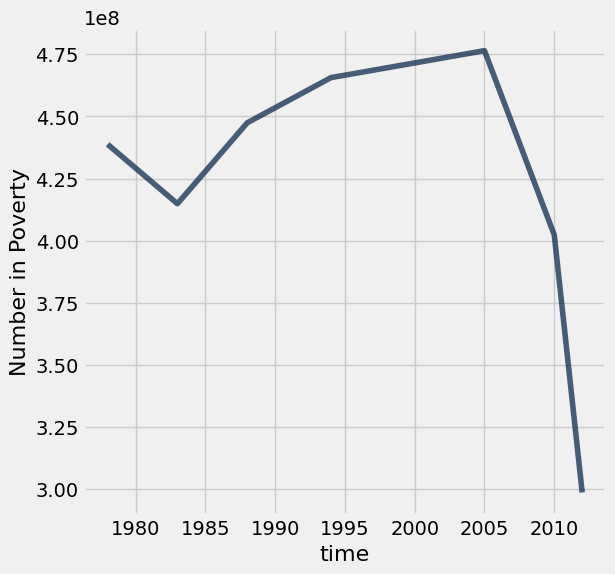

In [88]:
def poverty_timeline(country):
    t1 = poverty.join("geo", countries, "country").where("name", country)
    r1 = t1.column("time")
    r2 = population.join("geo", countries, "country").where("name", country).where("time", are.contained_in(r1)).column("population_total")
    t2 = t1.with_column("population_total", r2)
    r3 = (t2.column("extreme_poverty_percent_people_below_125_a_day")/100)*(t2.column("population_total"))
    t3 = t2.with_column("Number in Poverty", r3)
    return t3.plot("time", "Number in Poverty")

poverty_timeline("India")

Graph 5

<img src="Q2.6_graph.PNG"/> 

Finally, draw the timelines below to see how the world is changing. The timelines will show up in sequence; i.e., the first one is for India, second for Nigeria, etc.  You can check your work by comparing your graphs to the ones on [gapminder.org](https://www.gapminder.org/tools/#$state$entities$show$country$/$in@=ind;;;;&marker$axis_y$which=number_of_people_in_poverty&scaleType=linear&spaceRef:null;;;&chart-type=linechart).

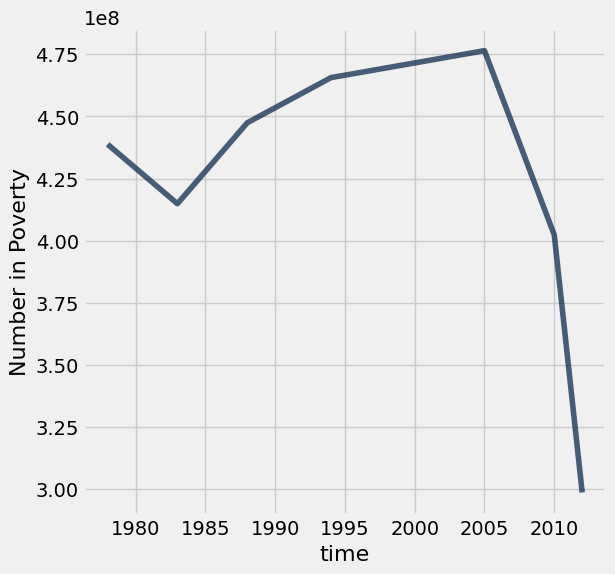

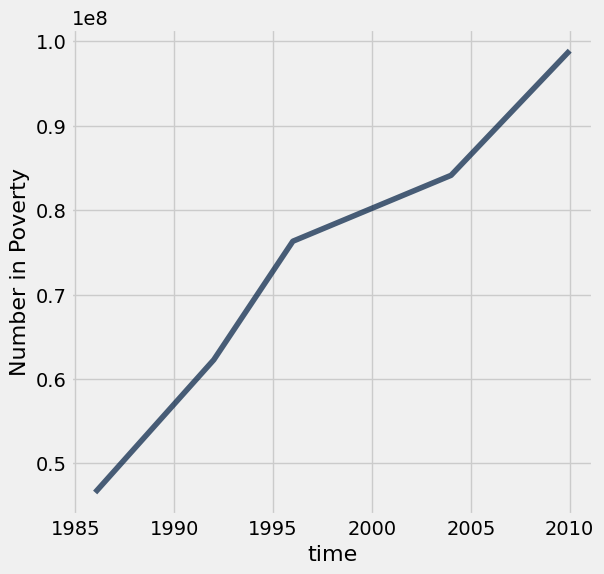

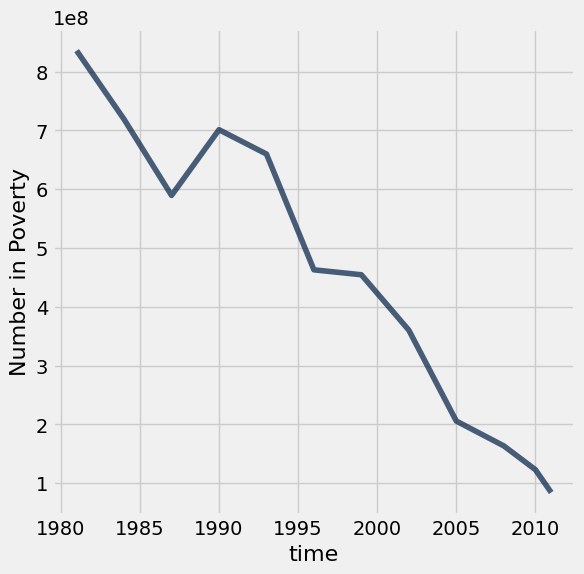

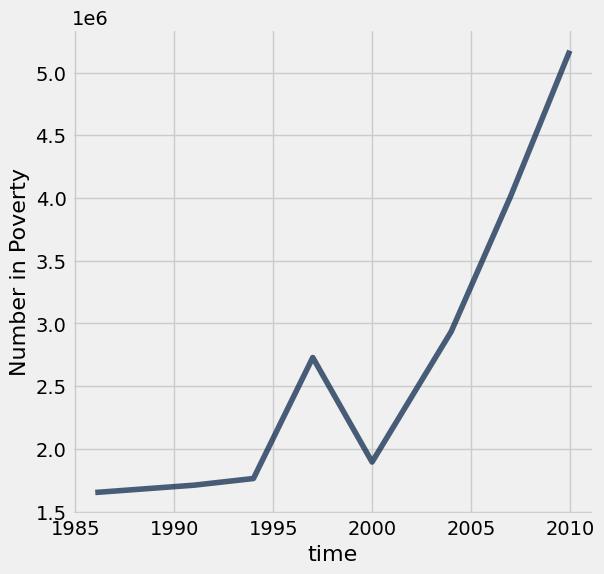

In [89]:
poverty_timeline('India')
poverty_timeline('Nigeria')
poverty_timeline('China')
poverty_timeline('United States')

Although the number of people living in extreme poverty increased in some countries including Nigeria and the United States, the decreases in other countries, most notably the massive decreases in China and India, have shaped the overall trend that extreme poverty is decreasing worldwide, both in percentage and in absolute number.

To learn more, watch [Hans Rosling in a 2015 film](https://www.gapminder.org/videos/dont-panic-end-poverty/) about the UN goal of eradicating extreme poverty from the world. 

---

To double-check your work, the cell below will rerun all of the autograder tests.

In [48]:
grader.check_all()

q1_1 results: All test cases passed!

q1_11 results: All test cases passed!

q1_12 results: All test cases passed!

q1_12_0 results: All test cases passed!

q1_13 results: All test cases passed!

q1_14 results: All test cases passed!

q1_2 results: All test cases passed!

q1_5 results: All test cases passed!

q1_7 results: All test cases passed!

q1_9 results: All test cases passed!

q2_1 results: All test cases passed!

q2_2 results: All test cases passed!

q2_3 results: All test cases passed!

q2_4 results: All test cases passed!

q2_5 results: All test cases passed!

### You're finished!
Congratulations on mastering data visualization and table manipulation. Please save, download, and submit your notebook in pdf form to Gradescope.